In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [22]:
data = load_breast_cancer()
X = data.data
y = data.target

X = pd.DataFrame(X, columns = data.feature_names)
y = pd.DataFrame(y, columns = ['target'])

data = pd.concat([X, y], axis = 1)

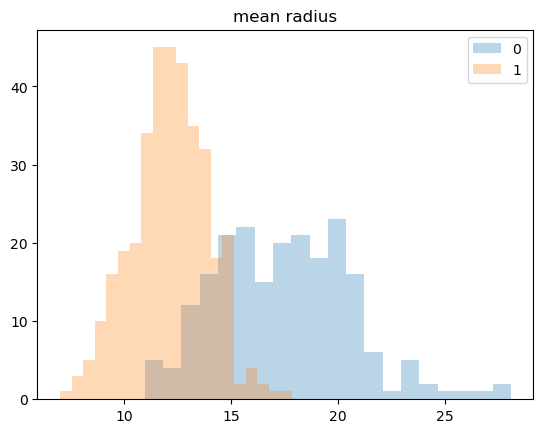

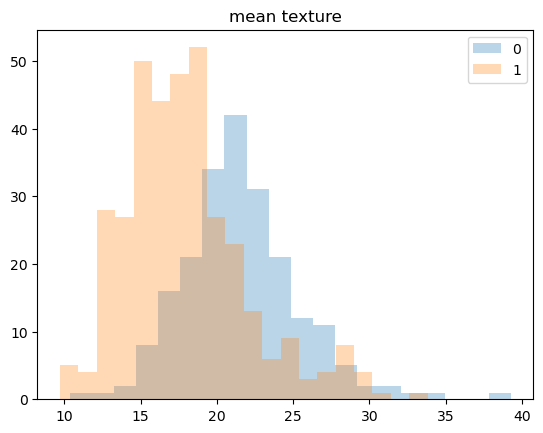

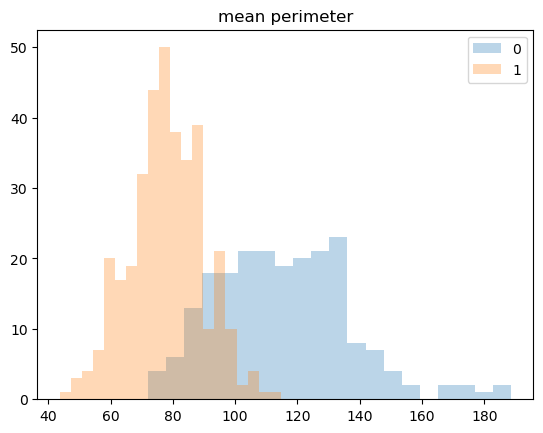

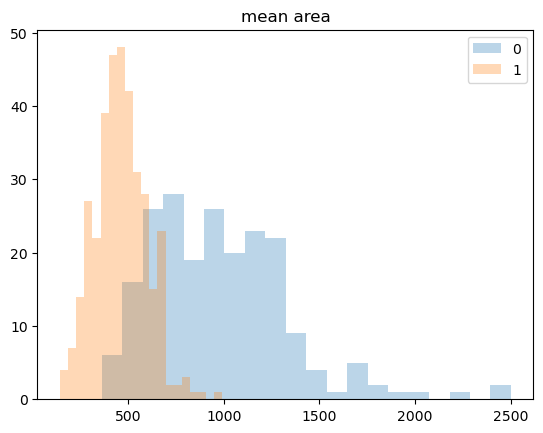

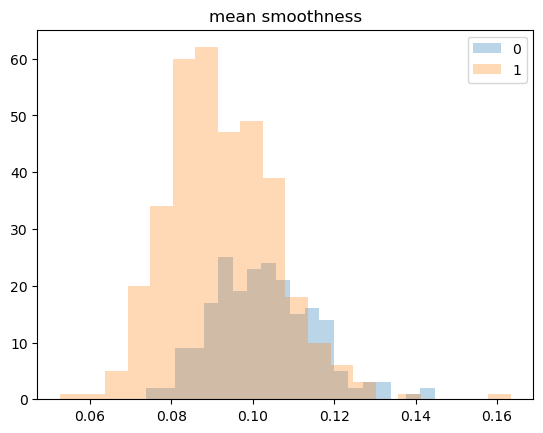

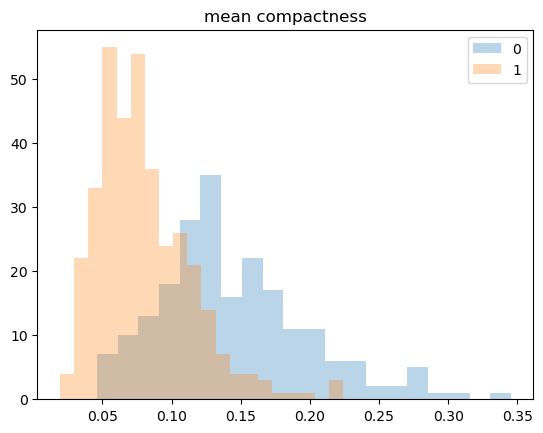

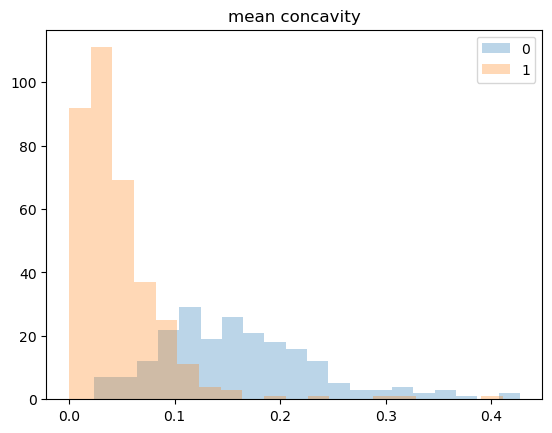

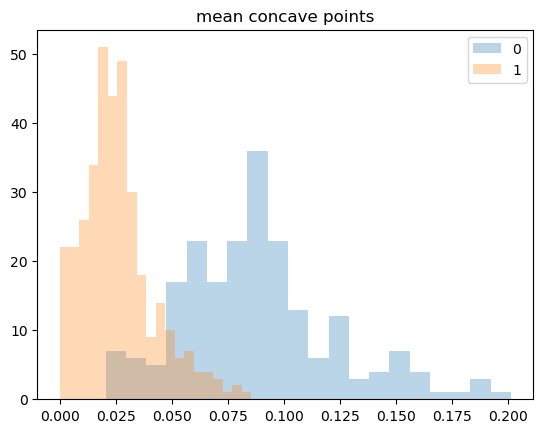

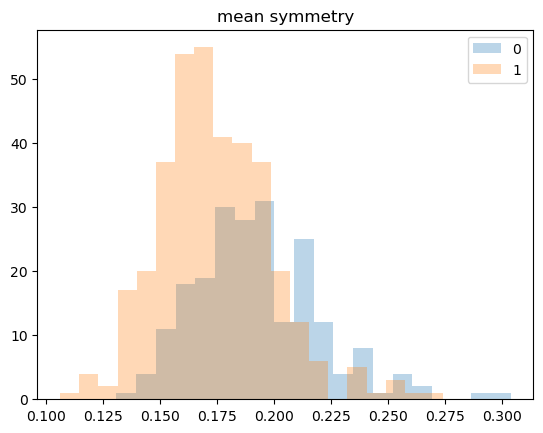

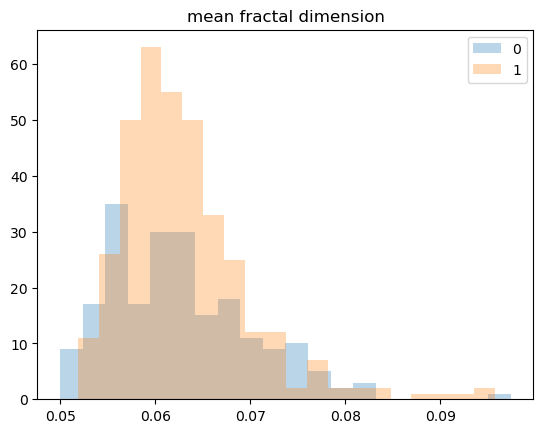

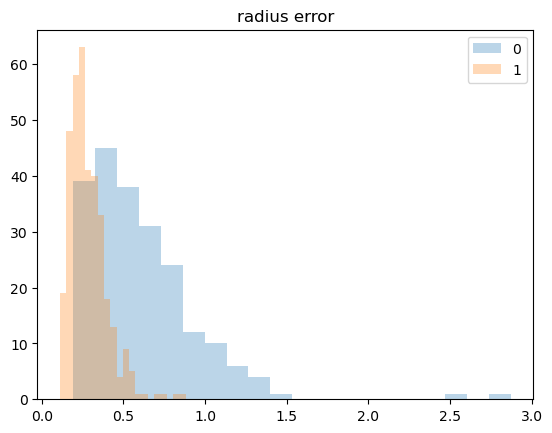

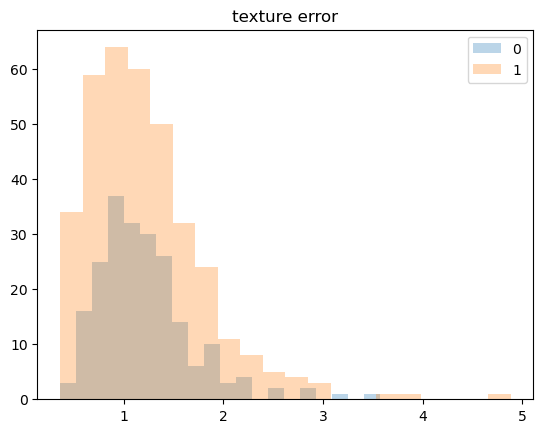

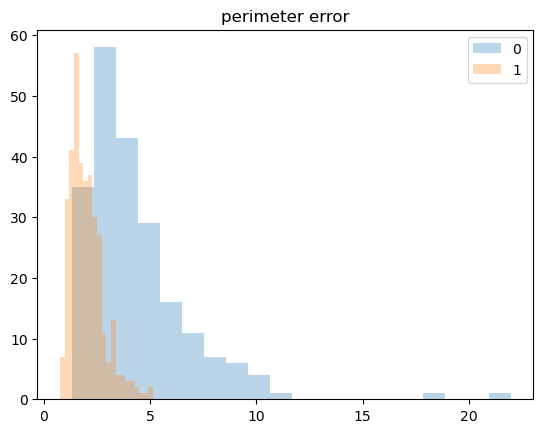

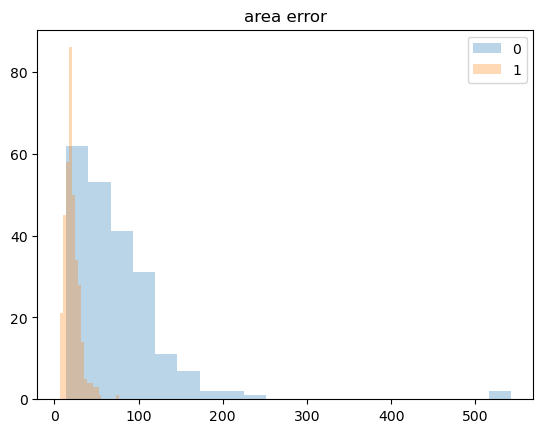

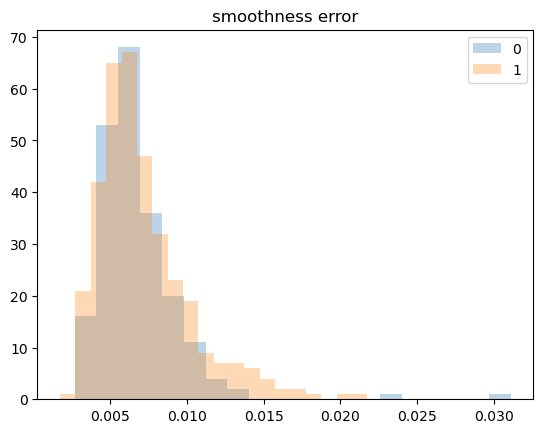

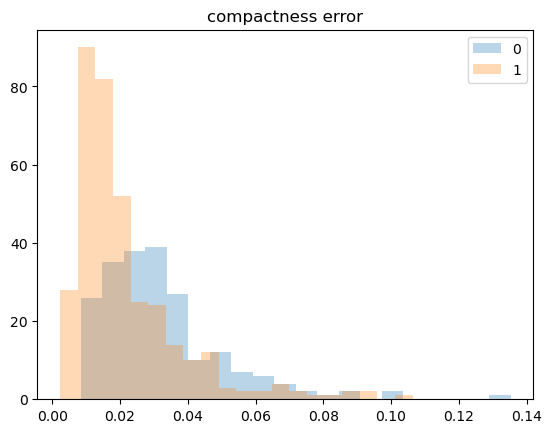

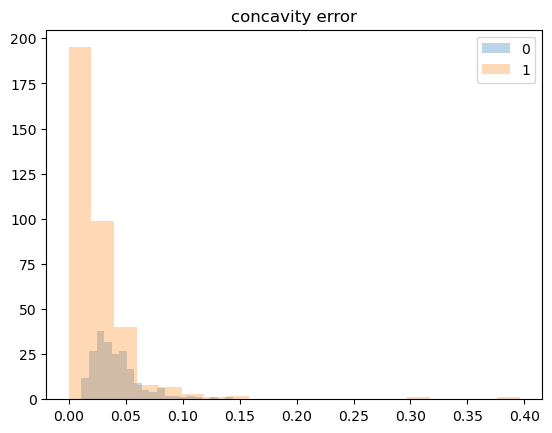

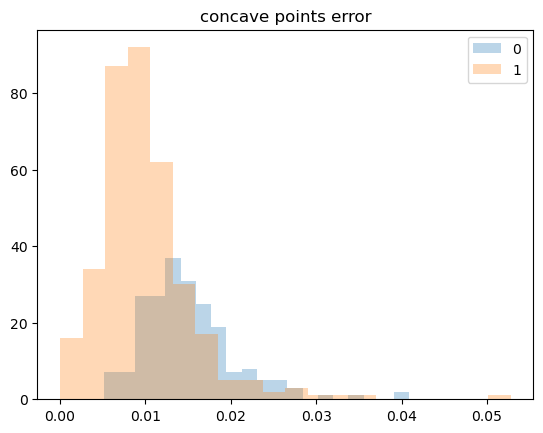

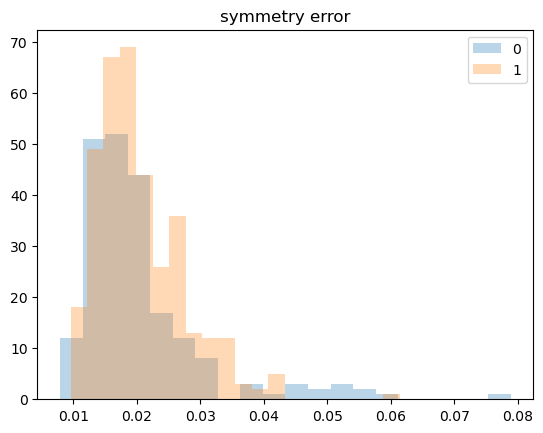

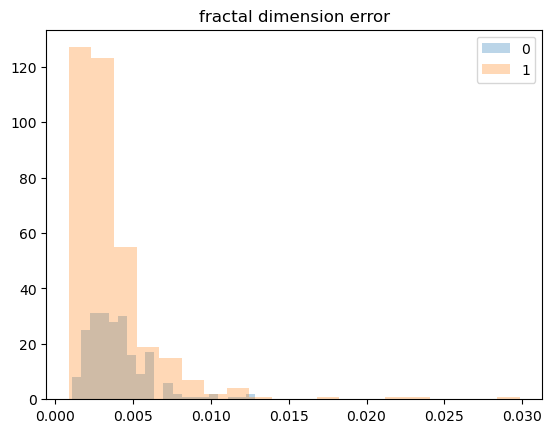

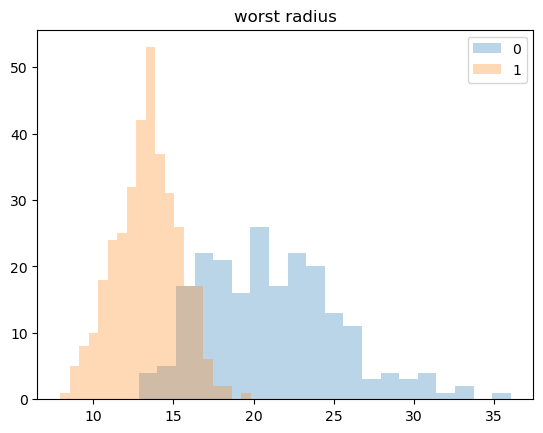

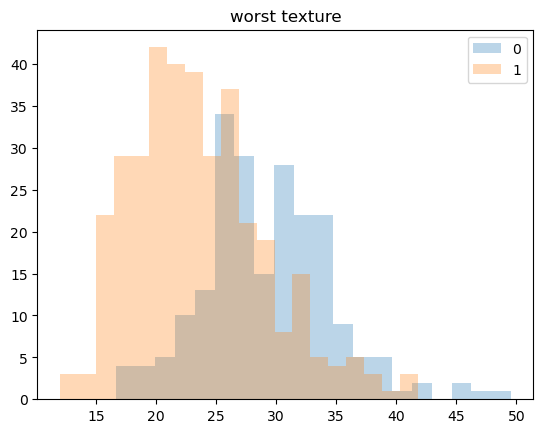

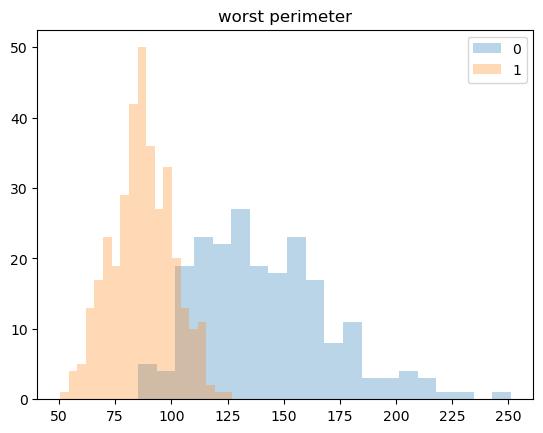

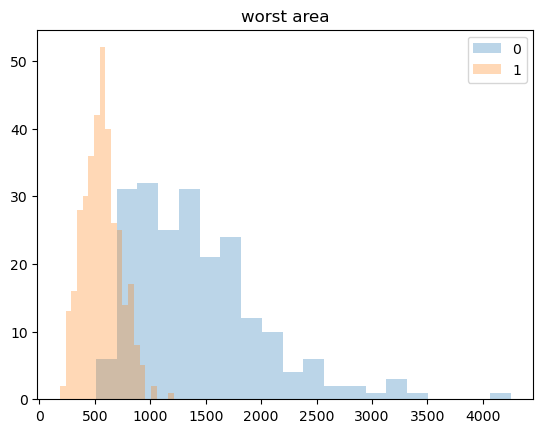

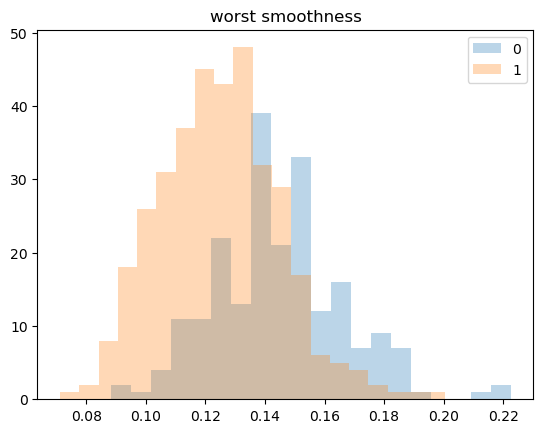

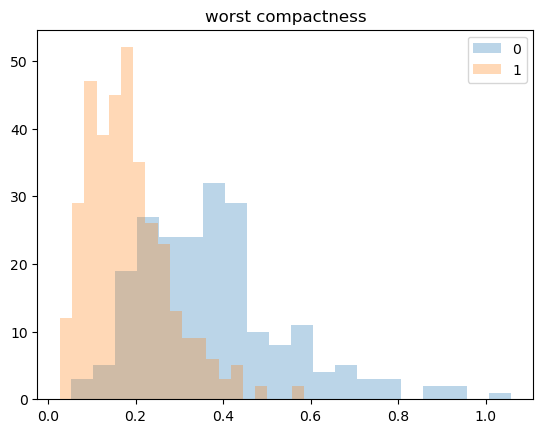

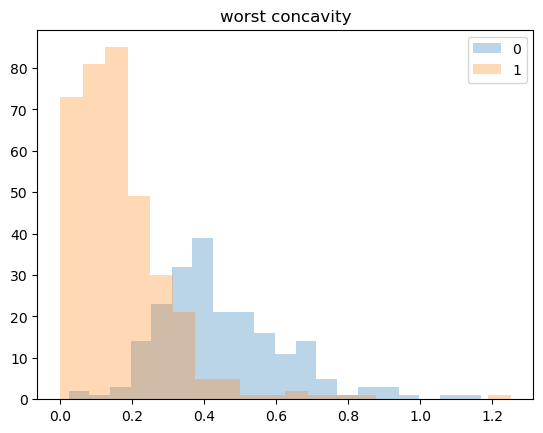

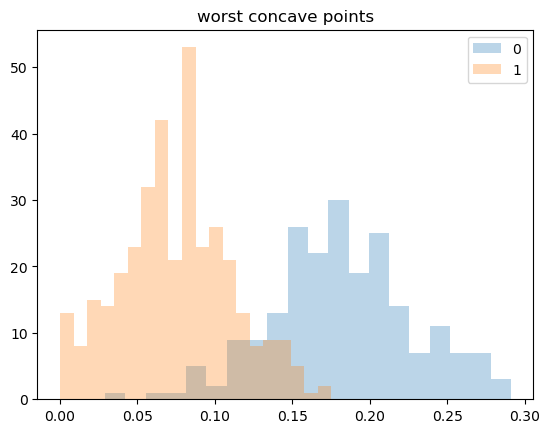

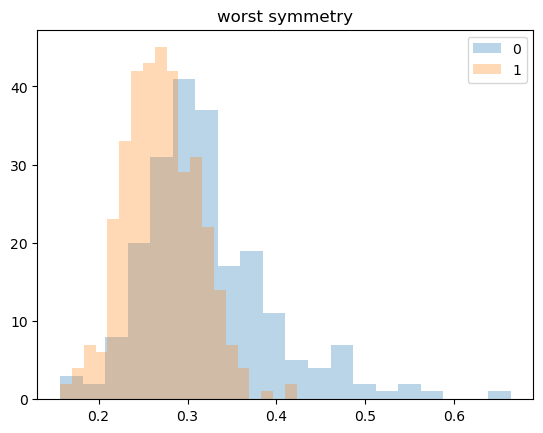

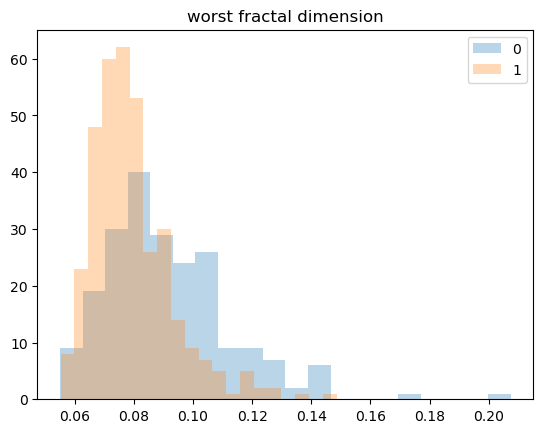

In [23]:
for feature in X.columns:
    for targ in y['target'].unique():
        df = data[data['target'] == targ]
        plt.hist(df[feature], bins = 20, alpha = 0.3, label = targ)
        plt.title(feature)
        plt.legend()
    plt.show()

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter = 5000))
])

param_grid = [
    {
        'model__penalty' : ['l1'],
        'model__C' : [0.01, 0.1, 1., 10.],
        'model__solver' : ['liblinear'],
        'model__class_weight' : ['balanced']
    },
    {
        'model__penalty' : ['l2'],
        'model__C' : [0.01, 0.1, 1., 10.],
        'model__solver': ['lbfgs'],
        'model__class_weight' : ['balanced']
    },
    {
        'model__penalty' : ['elasticnet'],
        'model__C' : [0.01, 0.1, 1., 10.],
        'model__l1_ratio' : np.linspace(0.1, 0.9, 10),
        'model__solver': ['saga'],
        'model__class_weight' : ['balanced']
    }
]

grid = GridSearchCV(pipe, param_grid, cv = StratifiedKFold(n_splits = 5, shuffle = True), scoring = 'accuracy')
grid.fit(X_train, np.array(y_train).ravel())
print(grid.best_params_)
model = grid.best_estimator_

coef = model.named_steps['model'].coef_
coef = pd.Series(coef.ravel(), index = X.columns)
coef = coef.sort_values(ascending = False)
print(coef)

{'model__C': 0.1, 'model__class_weight': 'balanced', 'model__l1_ratio': 0.1, 'model__penalty': 'elasticnet', 'model__solver': 'saga'}
fractal dimension error    0.228129
compactness error          0.215900
symmetry error             0.160162
mean fractal dimension     0.130448
concavity error            0.012426
mean compactness           0.000000
texture error              0.000000
mean symmetry              0.000000
smoothness error          -0.006400
worst fractal dimension   -0.041357
concave points error      -0.065984
worst compactness         -0.103027
mean smoothness           -0.111763
perimeter error           -0.305251
mean concavity            -0.309349
area error                -0.319308
mean area                 -0.335377
mean perimeter            -0.343648
mean radius               -0.357178
worst concavity           -0.380596
worst smoothness          -0.382308
mean texture              -0.397695
worst area                -0.428469
worst perimeter           -0.433435
wo

0.9824561403508771


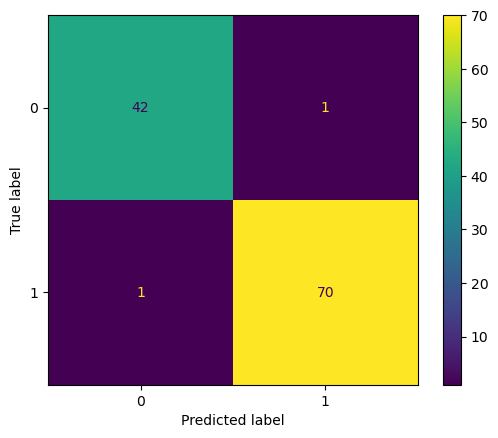

In [30]:
y_preds = model.predict(X_test)
print(accuracy_score(y_test, y_preds))
conf = confusion_matrix(y_test, y_preds)
disp = ConfusionMatrixDisplay(confusion_matrix = conf).plot()